# GRU — Speech Emotion Recognition

The GRU processes the MFCC sequence frame by frame, maintaining a hidden state across the full utterance. Unlike the MLP which discards temporal structure entirely, and the CNN which only captures local patterns, the GRU sees the entire temporal trajectory before making a decision.

GRU is chosen over LSTM because it has fewer parameters (2 gates vs 3) and is less prone to overfitting on small datasets. Both solve the vanishing gradient problem — GRU just does it more efficiently when data is limited.

## Imports

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import glob
import os
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from data_loader import prepare_data

## Config

In [10]:
DATASET_PATH  = "Audio_Speech_Actors_01-24"
MAX_LEN       = 300
BATCH_SIZE    = 32
N_EPOCHS      = 200
LR            = 0.01
DROPOUT       = 0.3
NOISE_STD     = 0.01   # std of gaussian noise added during training
PATIENCE      = 10     # early stopping

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

## Data Loading

Same features as the CNN: MFCC (40 channels) + RMS (1 channel). Deltas are dropped since the GRU learns temporal dynamics directly from the raw sequence.

`prepare_data` returns tensors of shape `(batch, features, time)`. The GRU expects `(batch, time, features)` because it processes one time step at a time, where each step is a feature vector. The permute call handles this transposition.

In [11]:
feature_files = glob.glob(os.path.join(DATASET_PATH, "Actor_*", "*.npz"))

[x_train_torch,
 y_train_torch,
 x_val_torch,
 y_val_torch,
 x_test_torch,
 y_test_torch] = prepare_data(feature_files=feature_files,
                              flatten=False,
                              features=['mfcc', 'rms'],
                              max_len=MAX_LEN)

# (batch, features, time) -> (batch, time, features)
x_train_torch = x_train_torch.permute(0, 2, 1)
x_val_torch   = x_val_torch.permute(0, 2, 1)
x_test_torch  = x_test_torch.permute(0, 2, 1)

print(f"Train: {x_train_torch.shape} | Val: {x_val_torch.shape} | Test: {x_test_torch.shape}")

Loading data: 100%|██████████| 1440/1440 [00:00<00:00, 1829.56it/s]


Train: torch.Size([960, 300, 41]) | Val: torch.Size([240, 300, 41]) | Test: torch.Size([240, 300, 41])


## Model

Two-layer GRU followed by two linear layers.

**`nn.GRU`** takes the sequence and at each time step updates its hidden state using the current input and the previous hidden state. `batch_first=True` matches our input shape of `(batch, time, features)`.

**`output[:, -1, :]`** takes the hidden state at the last time step only. This is the GRU's summary of the full utterance after processing all 300 frames.

**Hidden size reduced to 64** compared to the initial 128 to reduce overfitting — the previous run with 128 showed train loss going to zero while val loss climbed from epoch 25. Smaller capacity delays that divergence.

**No dropout inside `nn.GRU`** for `num_layers=1` — PyTorch raises a warning since dropout between recurrent layers only applies when there are at least 2 layers. With `num_layers=2` it is valid and applied between the two GRU layers.

In [12]:
class GRU(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.gru     = nn.GRU(input_size=41, hidden_size=64, num_layers=2, batch_first=True)
        self.fc1     = nn.Linear(64, 32)
        self.fc2     = nn.Linear(32, 8)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        output, _ = self.gru(x)
        x = output[:, -1, :]      # last time step: (batch, hidden_size)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)           # raw logits
        return x

## Training Setup

SGD with momentum chosen here instead of Adam. Adam adapts the learning rate per parameter and can converge to sharp minima that generalize poorly on small datasets. SGD with momentum is a slower but often more robust optimizer when overfitting is the main concern.

In [13]:
model     = GRU(dropout_rate=DROPOUT)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)

train_loader = DataLoader(TensorDataset(x_train_torch, y_train_torch), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_torch,   y_val_torch),   batch_size=BATCH_SIZE, shuffle=False)

## Training Loop

Gaussian noise is added to each training batch before the forward pass. This artificially perturbs the input and prevents the model from memorizing exact training examples. The noise std is small enough to not corrupt the signal.

Best weights by val loss are saved. Early stopping halts training if val loss does not improve for `PATIENCE` epochs.

In [ ]:
run_loss_vec      = []
val_loss_vec      = []
best_val_loss     = float('inf')
best_epoch        = 0
epochs_no_improve = 0

for epoch in range(N_EPOCHS):

    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = inputs + torch.randn_like(inputs) * NOISE_STD
        output = model(inputs)
        loss   = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    run_loss_vec.append(running_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_loss += criterion(model(inputs), labels).item()
    val_loss_vec.append(val_loss)

    print(f"Epoch {epoch+1}/{N_EPOCHS}  train: {running_loss:.4f}  val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_epoch        = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'gru_best.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"Best epoch: {best_epoch}")

Epoch 1/200  train: 62.3937  val: 16.5759
Epoch 2/200  train: 62.0969  val: 16.5049
Epoch 3/200  train: 61.8967  val: 16.4803
Epoch 4/200  train: 61.8332  val: 16.4678
Epoch 5/200  train: 61.8911  val: 16.4620
Epoch 6/200  train: 61.7428  val: 16.4475


## Loss Curves

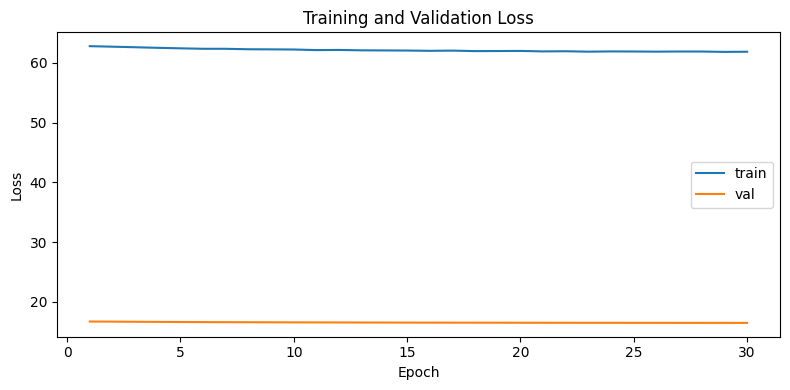

In [ ]:
epochs_ran = len(run_loss_vec)
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs_ran + 1), run_loss_vec, label='train')
plt.plot(range(1, epochs_ran + 1), val_loss_vec, label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
model.load_state_dict(torch.load('gru_best.pth'))
model.eval()

correct    = 0
total      = 0
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(classification_report(all_labels, all_preds, target_names=list(EMOTION_MAP.values())))
print(f'Val accuracy: {100 * correct / total:.2f}%')
print(f'Best epoch: {best_epoch}')
print(f"Val label distribution:   {np.bincount(y_val_torch.numpy())}")
print(f"Train label distribution: {np.bincount(y_train_torch.numpy())}")

              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00        16
        calm       0.00      0.00      0.00        32
       happy       0.00      0.00      0.00        32
         sad       0.13      0.97      0.23        32
       angry       0.00      0.00      0.00        32
     fearful       0.00      0.00      0.00        32
     disgust       0.29      0.06      0.10        32
   surprised       0.00      0.00      0.00        32

    accuracy                           0.14       240
   macro avg       0.05      0.13      0.04       240
weighted avg       0.06      0.14      0.04       240

Val accuracy: 13.75%
Best epoch: 30
Val label distribution:   [16 32 32 32 32 32 32 32]
Train label distribution: [ 64 128 128 128 128 128 128 128]


c:\Users\yotam\Documents\University\self learning\Emotion recognition from speech\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yotam\Documents\University\self learning\Emotion recognition from speech\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yotam\Documents\University\self learning\Emotion recognition from speech\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi